# Routing-Targets vor und nach dem Classifier-Finetuning

Dieses Notebook inferiert die alten und die gefinetunten Classifier **live auf denselben, ungeshuffelten Samples**.

- `r1_target = 1`, wenn `f_small` falsch klassifiziert (Weiterleitung an `f_mid`).
- `r2_target = 1`, wenn `f_mid` falsch klassifiziert (Weiterleitung an `f_large`).
- Die kaskadische Route ist `f_small`, wenn R1 nicht rejected, sonst `f_mid`, wenn R2 nicht rejected, sonst `f_large`.

`f_large` wird nicht geladen, da sein Output für diese Target-Definition nicht benötigt wird. Für R2 wird die Eingabemenge auf den **alten R1-Rejects** eingefroren. Insbesondere wird kein neues Validation-Subset aus den neuen R1-Targets gebildet; altes und neues `f_mid` werden auf exakt denselben Samples verglichen.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "finetune":
    PROJECT_DIR = PROJECT_DIR.parent
elif not (PROJECT_DIR / "training_models.py").exists():
    PROJECT_DIR = Path("/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training")
sys.path.insert(0, str(PROJECT_DIR))

import training
import training_models
from DMTimeShardDataset import DMTimeShardDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 1024
NUM_WORKERS = 4
SPLITS = ("train", "val")  # Bei Bedarf um "test" erweitern.
SAVE_RESULTS = False
OUTPUT_DIR = PROJECT_DIR / "finetune" / "routing_target_comparison"

DATASET_CFG = {
    "output_dir": "/cephfs/users/oleksjuk/MA/WP2-1/DM_time_dataset_creator/outputs",
    "prefix": "B0531+21_59000_48386",
}

CHECKPOINTS = {
    "small_old": PROJECT_DIR / "final_checkpoints/baseline_rejection_ensemble/prot-DM_time_binary_classificator_241002_3_GAP-014-0.764-0.740.pth",
    "small_new": PROJECT_DIR / "finetune_checkpoints_classifiers/f_small/RandomSearch_Finetune_f_small_Container1/trial3_lr3.00e-05_wd0.00e+00_dropFalse/prot-DM_time_binary_classificator_241002_3_GAP_finetune-004-0.838-0.813.pth",
    "mid_old": PROJECT_DIR / "final_checkpoints/baseline_rejection_ensemble/prot-DM_time_binary_classificator_241002_5_GAP-060-0.973-0.948.pth",
    "mid_new": PROJECT_DIR / "finetune_checkpoints_classifiers/f_mid/RandomSearch_Finetune_f_mid_Container3/trial4_lr1.00e-04_wd0.00e+00_dropFalse/prot-DM_time_binary_classificator_241002_5_GAP_finetune-019-0.989-0.993.pth",
}

print(f"device: {DEVICE}")
for name, path in CHECKPOINTS.items():
    if not path.is_file():
        raise FileNotFoundError(f"Checkpoint fehlt ({name}): {path}")
    print(f"{name:>9}: {path}")

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda
small_old: /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/final_checkpoints/baseline_rejection_ensemble/prot-DM_time_binary_classificator_241002_3_GAP-014-0.764-0.740.pth
small_new: /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/finetune_checkpoints_classifiers/f_small/RandomSearch_Finetune_f_small_Container1/trial3_lr3.00e-05_wd0.00e+00_dropFalse/prot-DM_time_binary_classificator_241002_3_GAP_finetune-004-0.838-0.813.pth
  mid_old: /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/final_checkpoints/baseline_rejection_ensemble/prot-DM_time_binary_classificator_241002_5_GAP-060-0.973-0.948.pth
  mid_new: /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/finetune_checkpoints_classifiers/f_mid/RandomSearch_Finetune_f_mid_Container3/trial4_lr1.00e-04_wd0.00e+00_dropFalse/prot-DM_time_binary_classificator_241002_5_GAP_finetune-019-0.989-0.993.pth


In [2]:
def extract_state_dict(checkpoint):
    if isinstance(checkpoint, dict):
        for key in ("model_state_dict", "state_dict", "model"):
            if isinstance(checkpoint.get(key), dict):
                return checkpoint[key]
    return checkpoint


def load_classifier(model_name, mode, checkpoint_path):
    model = training_models.models_htable[model_name](
        256, mode=mode, dropout=False, device=DEVICE
    ).to(DEVICE)
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(extract_state_dict(checkpoint))
    model.eval()
    return model


models = {
    "small_old": load_classifier(
        "DM_time_binary_classificator_241002_3_GAP", "dmt", CHECKPOINTS["small_old"]
    ),
    "small_new": load_classifier(
        "DM_time_binary_classificator_241002_3_GAP", "dmt", CHECKPOINTS["small_new"]
    ),
    # Gleiche Architektur und exakt der Baseline-Checkpoint des f_mid-Finetunings.
    "mid_old": load_classifier(
        "DM_time_binary_classificator_241002_5_GAP", "ft", CHECKPOINTS["mid_old"]
    ),
    "mid_new": load_classifier(
        "DM_time_binary_classificator_241002_5_GAP", "ft", CHECKPOINTS["mid_new"]
    ),
}

print("Alle vier Classifier wurden geladen.")

Alle vier Classifier wurden geladen.


In [3]:
datasets = {}
loaders = {}

for split in SPLITS:
    dataset = DMTimeShardDataset(DATASET_CFG, use_freq_time=True, split=split)
    dataset.labels = training.label_encoding(dataset.labels.astype(object))
    datasets[split] = dataset
    loaders[split] = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,  # Für den 1:1-Vergleich zwingend unverändert lassen.
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
        persistent_workers=NUM_WORKERS > 0,
    )
    print(f"{split:>5}: {len(dataset):,} Samples")

Converting string labels to numeric: ['Artefact' 'Pulse'] -> [0, 1]
train: 1,377,792 Samples
Converting string labels to numeric: ['Artefact' 'Pulse'] -> [0, 1]
  val: 172,032 Samples


## Live-Inferenz

Alle vier Modelle sehen innerhalb eines Batches exakt dieselben Samples. `sample_index` entspricht der Position im jeweiligen Original-Split; es wird kein balancierter oder geshuffelter Target-Cache verwendet.

In [4]:
@torch.inference_mode()
def infer_split(loader, split):
    labels = []
    predictions = {name: [] for name in models}

    for batch in tqdm(loader, desc=f"Infer {split}"):
        labels.append(batch["label"].detach().cpu().numpy().reshape(-1))
        for name, model in models.items():
            logits = model(batch)
            predictions[name].append(logits.argmax(dim=1).detach().cpu().numpy())

    y = np.concatenate(labels).astype(np.int64, copy=False)
    pred = {name: np.concatenate(parts) for name, parts in predictions.items()}

    frame = pd.DataFrame({
        "split": split,
        "sample_index": np.arange(len(y), dtype=np.int64),
        "label": y,
        **{f"pred_{name}": values for name, values in pred.items()},
    })

    frame["r1_target_old"] = (pred["small_old"] != y).astype(np.int8)
    frame["r1_target_new"] = (pred["small_new"] != y).astype(np.int8)
    frame["r2_target_old"] = (pred["mid_old"] != y).astype(np.int8)
    frame["r2_target_new"] = (pred["mid_new"] != y).astype(np.int8)

    # 0=f_small, 1=f_mid, 2=f_large. R2 zählt nur, wenn R1 zuvor rejected hat.
    frame["route_old"] = np.where(
        frame["r1_target_old"].eq(0), 0,
        np.where(frame["r2_target_old"].eq(0), 1, 2),
    ).astype(np.int8)
    # Für den vergleichbaren R2-Vergleich bleibt die alte R1-Auswahl fest.
    frame["route_new_fixed_r1"] = np.where(
        frame["r1_target_old"].eq(0), 0,
        np.where(frame["r2_target_new"].eq(0), 1, 2),
    ).astype(np.int8)
    return frame


results = {split: infer_split(loaders[split], split) for split in SPLITS}
comparison = pd.concat(results.values(), ignore_index=True)
comparison.head()

Infer val: 100%|██████████| 168/168 [01:13<00:00,  2.28it/s]


,split,sample_index,label,pred_small_old,pred_small_new,pred_mid_old,pred_mid_new,r1_target_old,r1_target_new,r2_target_old,r2_target_new,route_old,route_new_fixed_r1
0,train,0,0,0,0,0,0,0,0,0,0,0,0
1,train,1,0,0,0,0,0,0,0,0,0,0,0
2,train,2,0,0,0,0,0,0,0,0,0,0,0
3,train,3,0,0,0,0,0,0,0,0,0,0,0
4,train,4,1,1,1,1,1,0,0,0,0,0,0


## Target-Abweichungen

`0 → 1` sind neu zusätzlich rejected Samples, `1 → 0` sind durch das Finetuning neu korrekt klassifizierte Samples. R1 wird auf dem vollständigen Split verglichen. R2 wird ausschließlich auf dem festen alten R1-Reject-Subset verglichen.

In [5]:
def target_summary(frame, stage):
    old = frame[f"{stage}_target_old"].to_numpy()
    new = frame[f"{stage}_target_new"].to_numpy()
    return {
        "samples": len(frame),
        "old_rejects": int(old.sum()),
        "new_rejects": int(new.sum()),
        "old_reject_rate": old.mean(),
        "new_reject_rate": new.mean(),
        "changed": int(np.count_nonzero(old != new)),
        "changed_rate": np.mean(old != new),
        "0_to_1": int(np.count_nonzero((old == 0) & (new == 1))),
        "1_to_0": int(np.count_nonzero((old == 1) & (new == 0))),
    }


summary_rows = []
for split, frame in results.items():
    summary_rows.append({"split": split, "stage": "r1", **target_summary(frame, "r1")})
    old_r2_input = frame["r1_target_old"].eq(1)
    summary_rows.append({
        "split": split,
        "stage": "r2 (fixed old r1 subset)",
        **target_summary(frame.loc[old_r2_input], "r2"),
    })

target_summary_df = pd.DataFrame(summary_rows).set_index(["split", "stage"])
target_summary_df.style.format({
    "old_reject_rate": "{:.3%}",
    "new_reject_rate": "{:.3%}",
    "changed_rate": "{:.3%}",
})

In [6]:
def transition_table(frame, old_col, new_col, labels=None):
    table = pd.crosstab(
        frame[old_col], frame[new_col],
        rownames=[f"old: {old_col}"], colnames=[f"new: {new_col}"],
        dropna=False,
    )
    if labels is not None:
        table = table.reindex(index=labels, columns=labels, fill_value=0)
    return table


for split, frame in results.items():
    print(f"\n===== {split.upper()} =====")
    print("R1 target transition")
    display(transition_table(frame, "r1_target_old", "r1_target_new", labels=[0, 1]))
    old_r2_input = frame["r1_target_old"].eq(1)
    print(f"R2 target transition (festes altes R1-Subset: {old_r2_input.sum():,} Samples)")
    display(transition_table(
        frame.loc[old_r2_input], "r2_target_old", "r2_target_new", labels=[0, 1]
    ))


===== TRAIN =====
R1 target transition


new: r1_target_new,0,1
old: r1_target_old,,
0,1046684,6951
1,6386,317771


R2 target transition (festes altes R1-Subset: 324,157 Samples)


new: r2_target_new,0,1
old: r2_target_old,,
0,310303,2069
1,3357,8428



===== VAL =====
R1 target transition


new: r1_target_new,0,1
old: r1_target_old,,
0,126660,637
1,762,43973


R2 target transition (festes altes R1-Subset: 44,735 Samples)


new: r2_target_new,0,1
old: r2_target_old,,
0,39289,534
1,837,4075


## Kaskadischer Vergleich

Beide Mid-Modelle werden ausschließlich auf den Samples verglichen, die nach dem **alten** R1-Target weitergeleitet wurden (`r1_target_old == 1`). Dasselbe feste Auswahlverfahren gilt für Train und Validation. So isoliert der Vergleich den Einfluss des Mid-Finetunings auf die bisherigen R2-Samples; das neue Small-Modell erzeugt hier ausdrücklich kein neues R2-Subset.

Da im Notebook `1 = REJECT = Classifier falsch` gilt, sind die Targets gegenüber einem `accept = Classifier korrekt`-Boolean invertiert. Die Target-Änderungsrate ist davon unabhängig.

In [7]:
ROUTE_NAMES = {0: "f_small", 1: "f_mid", 2: "f_large"}
cascade_rows = []

for split, frame in results.items():
    old_r1 = frame["r1_target_old"].eq(1)
    # Variante A: exakt derselbe R2-Input wie vor dem Finetuning.
    old_r2_input = old_r1
    old_input_changed = (
        frame.loc[old_r2_input, "r2_target_old"] != frame.loc[old_r2_input, "r2_target_new"]
    )
    cascade_rows.append({
        "split": split,
        "fixed_old_r2_input": int(old_r2_input.sum()),
        "r2_changed": int(old_input_changed.sum()),
        "r2_changed_rate": old_input_changed.mean() if old_r2_input.any() else np.nan,
        "fixed_r1_route_changed": int((frame["route_old"] != frame["route_new_fixed_r1"]).sum()),
        "fixed_r1_route_changed_rate": (frame["route_old"] != frame["route_new_fixed_r1"]).mean(),
    })

cascade_summary_df = pd.DataFrame(cascade_rows).set_index("split")
display(cascade_summary_df.style.format({
    "r2_changed_rate": "{:.3%}",
    "fixed_r1_route_changed_rate": "{:.3%}",
}))

for split, frame in results.items():
    route_table = transition_table(frame, "route_old", "route_new_fixed_r1", labels=[0, 1, 2])
    route_table = route_table.rename(index=ROUTE_NAMES, columns=ROUTE_NAMES)
    print(f"\n{split.upper()}: Route old → new (festes altes R1-Subset)")
    display(route_table)

,fixed_old_r2_input,r2_changed,r2_changed_rate,fixed_r1_route_changed,fixed_r1_route_changed_rate
split,,,,,
train,324157,5426,1.674%,5426,0.394%
val,44735,1371,3.065%,1371,0.797%



TRAIN: Route old → new (festes altes R1-Subset)


new: route_new_fixed_r1,f_small,f_mid,f_large
old: route_old,,,
f_small,1053635,0,0
f_mid,0,310303,2069
f_large,0,3357,8428



VAL: Route old → new (festes altes R1-Subset)


new: route_new_fixed_r1,f_small,f_mid,f_large
old: route_old,,,
f_small,127297,0,0
f_mid,0,39289,534
f_large,0,837,4075


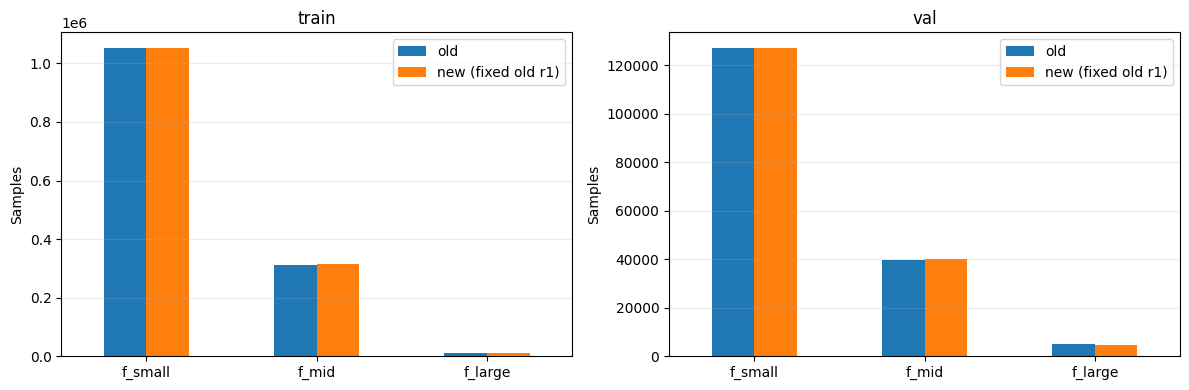

In [8]:
fig, axes = plt.subplots(1, len(SPLITS), figsize=(6 * len(SPLITS), 4), squeeze=False)
for ax, split in zip(axes[0], SPLITS):
    frame = results[split]
    route_counts = pd.DataFrame({
        "old": frame["route_old"].value_counts().reindex([0, 1, 2], fill_value=0),
        "new (fixed old r1)": frame["route_new_fixed_r1"].value_counts().reindex([0, 1, 2], fill_value=0),
    })
    route_counts.index = [ROUTE_NAMES[i] for i in route_counts.index]
    route_counts.plot.bar(ax=ax, rot=0)
    ax.set_title(split)
    ax.set_ylabel("Samples")
    ax.grid(axis="y", alpha=0.25)
plt.tight_layout()

## Optional: ausgerichtete Targets speichern

Die Dateien enthalten unbalancierte Targets und den Original-Index. Dadurch können einzelne Abweichungen später ohne Unsicherheit durch Shuffling untersucht werden.

In [9]:
if SAVE_RESULTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    columns = [
        "sample_index", "label",
        "pred_small_old", "pred_small_new", "pred_mid_old", "pred_mid_new",
        "r1_target_old", "r1_target_new", "r2_target_old", "r2_target_new",
        "route_old", "route_new_fixed_r1",
    ]
    for split, frame in results.items():
        output_path = OUTPUT_DIR / f"routing_targets_old_vs_finetuned_{split}.npz"
        np.savez_compressed(output_path, **{column: frame[column].to_numpy() for column in columns})
        print(f"Saved: {output_path}")
else:
    print("SAVE_RESULTS=False – es wurden keine Dateien geschrieben.")

SAVE_RESULTS=False – es wurden keine Dateien geschrieben.
